In [1]:
# Cell 1 — install deps (first run only) + imports + seed
%pip install -q -r requirements.txt
import time
from pathlib import Path

import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display
from PIL import Image
from tqdm.auto import tqdm

from mosaic_core import (
    MosaicConfig,
    build_faiss_index,
    build_report,
    ensure_seed_tiles,
    export_deepzoom,
    knn_candidates,
    render_mosaic,
    rerank,
    scan_tile_pool,
    split_target,
)

np.random.seed(0)

DEPRECATION: Loading egg at /Users/joejiang/miniconda3/lib/python3.12/site-packages/mdurl-0.1.2-py3.12.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /Users/joejiang/miniconda3/lib/python3.12/site-packages/ninja-1.11.1.1-py3.12-macosx-11.1-arm64.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /Users/joejiang/miniconda3/lib/python3.12/site-packages/rich-13.9.4-py3.12.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /Users/joejiang/miniconda3/lib/python3.12/site-packages/m


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


In [2]:
# Cell 2 — config & interactive sliders
config = MosaicConfig()

tile_dir_w = widgets.Text(value=str(config.tile_dir), description='tile_dir')
target_w = widgets.Text(value=str(config.target_path), description='target')
grid_w_w = widgets.IntSlider(value=config.grid_w, min=20, max=240, step=4, description='grid_w')
grid_h_w = widgets.IntSlider(value=config.grid_h, min=12, max=135, step=2, description='grid_h')
lambda_w = widgets.FloatSlider(value=config.lambda_repeat, min=0.0, max=5.0, step=0.05, description='λ repeat')
mu_w = widgets.FloatSlider(value=config.mu_neighbor, min=0.0, max=5.0, step=0.05, description='μ neighbor')
tau_w = widgets.FloatSlider(value=config.tau_transfer, min=0.0, max=1.0, step=0.02, description='τ transfer')

def _sync(change=None):
    config.tile_dir = Path(tile_dir_w.value)
    config.target_path = Path(target_w.value) if target_w.value else None
    config.grid_w = grid_w_w.value
    config.grid_h = grid_h_w.value
    config.lambda_repeat = lambda_w.value
    config.mu_neighbor = mu_w.value
    config.tau_transfer = tau_w.value

for w in (tile_dir_w, target_w, grid_w_w, grid_h_w, lambda_w, mu_w, tau_w):
    w.observe(_sync, names='value')
_sync()

display(widgets.VBox([tile_dir_w, target_w, grid_w_w, grid_h_w, lambda_w, mu_w, tau_w]))

In [3]:
# Cell 3 — load / seed tile pool
ensure_seed_tiles(config.tile_dir)
tile_records, bad_files = scan_tile_pool(config.tile_dir, config.cache_path)
print(f'扫到 {len(tile_records)} 张 tile,坏图 {len(bad_files)} 张。')

扫到 200 张 tile,坏图 0 张。


⚠️  目标图 target.jpg 不存在,使用内置渐变兜底
目标 LAB grid shape = (68, 120, 3)


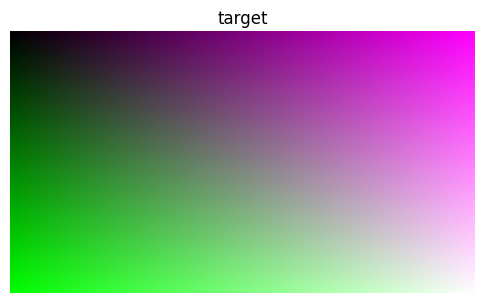

In [4]:
# Cell 4 — load target image, fallback to gradient if missing
def _fallback_target(w=768, h=432):
    grad = np.linspace(0, 255, w, dtype=np.uint8)[None, :, None].repeat(h, axis=0).repeat(3, axis=2)
    grad[..., 1] = np.linspace(0, 255, h, dtype=np.uint8)[:, None]
    return Image.fromarray(grad)

if config.target_path and config.target_path.exists():
    target_img = Image.open(config.target_path).convert('RGB')
else:
    print(f'⚠️  目标图 {config.target_path} 不存在,使用内置渐变兜底')
    target_img = _fallback_target()

target_lab = split_target(target_img, config.grid_w, config.grid_h)
print(f'目标 LAB grid shape = {target_lab.shape}')
plt.figure(figsize=(6, 4))
plt.imshow(target_img)
plt.title('target')
plt.axis('off')
plt.show()

In [5]:
# Cell 5 — KNN candidates + per-cell rerank with visible reasoning
tile_labs = np.stack([t.lab_mean for t in tile_records]).astype(np.float32)
index = build_faiss_index(tile_labs)
candidates = knn_candidates(target_lab, index, k=config.k_candidates)

grid_h, grid_w = target_lab.shape[:2]
assignment = np.zeros((grid_h, grid_w), dtype=np.int64)
usage_counts: dict[int, int] = {}
t0 = time.time()
total = grid_h * grid_w

for flat in tqdm(range(total), desc='matching'):
    r, c = divmod(flat, grid_w)
    cand = candidates[flat]
    neighbors = []
    if c > 0: neighbors.append(int(assignment[r, c - 1]))
    if r > 0: neighbors.append(int(assignment[r - 1, c]))
    best = rerank(cand, tile_labs, target_lab[r, c], usage_counts, neighbors,
                  config.lambda_repeat, config.mu_neighbor)
    assignment[r, c] = best
    usage_counts[best] = usage_counts.get(best, 0) + 1
    if flat % 50 == 0 and tile_records[best].path is not None:
        print(f'  ({r:>3},{c:>3}) -> {tile_records[best].path.name}')

elapsed = time.time() - t0
print(f'匹配完成,耗时 {elapsed:.2f} 秒')

matching:   0%|          | 0/8160 [00:00<?, ?it/s]

  (  0,  0) -> seed_0166.jpg


  (  0, 50) -> seed_0049.jpg
  (  0,100) -> seed_0152.jpg


  (  1, 30) -> seed_0011.jpg

  (  1, 80) -> seed_0029.jpg

...

  ( 64, 20) -> seed_0175.jpg
  ( 64, 70) -> seed_0167.jpg


  ( 65,  0) -> seed_0175.jpg
  ( 65, 50) -> seed_0059.jpg


  ( 65,100) -> seed_0096.jpg
  ( 66, 30) -> seed_0175.jpg
  ( 66, 80) -> seed_0167.jpg


  ( 67, 10) -> seed_0175.jpg


  ( 67, 60) -> seed_0059.jpg
  ( 67,110) -> seed_0096.jpg
匹配完成,耗时 41.43 秒


saved out/mosaic.png


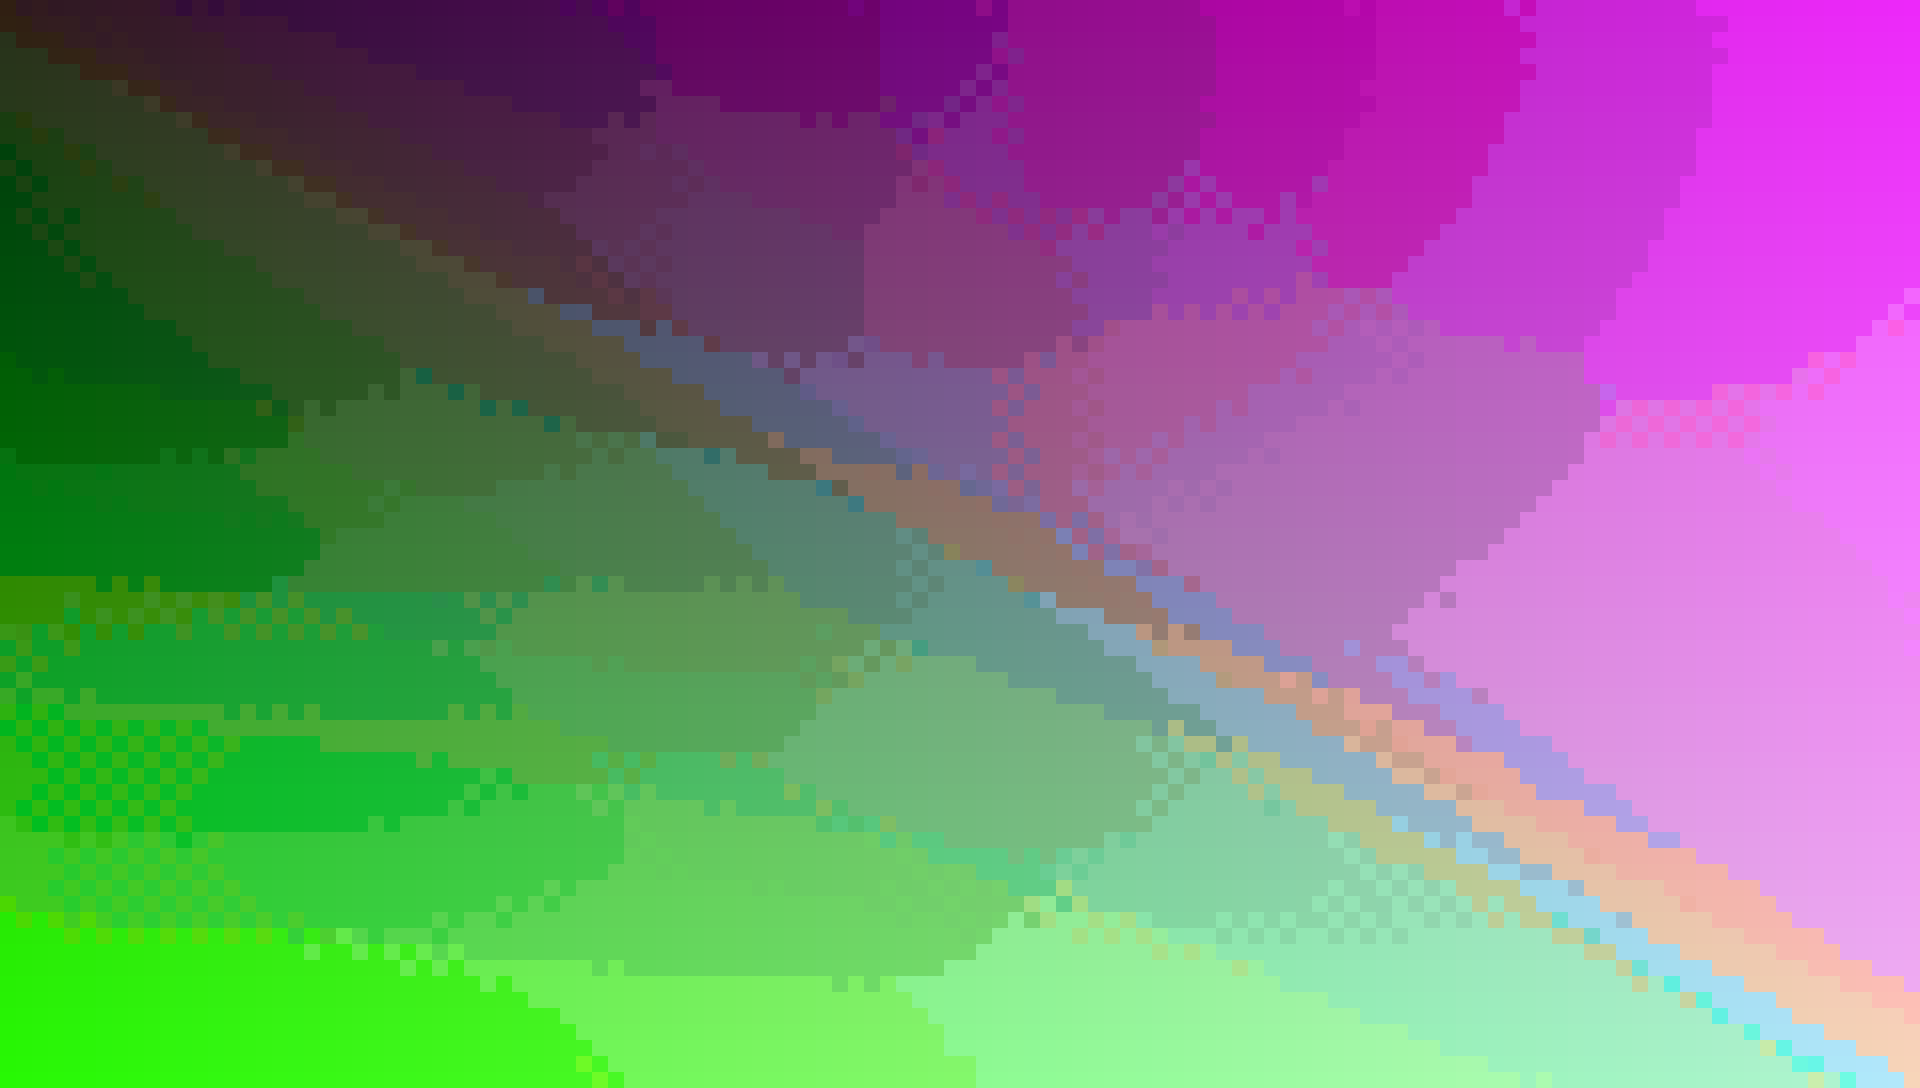

In [6]:
# Cell 6 — render mosaic
mosaic_img = render_mosaic(assignment, tile_records, config.tile_px,
                           config.tau_transfer, target_lab)
config.out_dir.mkdir(parents=True, exist_ok=True)
mosaic_path = config.out_dir / 'mosaic.png'
mosaic_img.save(mosaic_path)
print(f'saved {mosaic_path}')
display(mosaic_img)

本次扫到 200 张 tile,跑了 41.43 秒,生成了 8160 个格子。
坏图 0 张,冷宫照片 93 张。

TOP 5 最常被贴:
  seed_0168.jpg: 656 次
  seed_0020.jpg: 363 次
  seed_0137.jpg: 352 次
  seed_0175.jpg: 311 次
  seed_0152.jpg: 272 次

冷宫照片(前 5):
  seed_0003.jpg
  seed_0007.jpg
  seed_0009.jpg
  seed_0010.jpg
  seed_0012.jpg


/Users/joejiang/chrome_extension_perf_monitor/Tile.Photo/chatgpt/mosaic_core.py:328: UserWarning: Glyph 20919 (\N{CJK UNIFIED IDEOGRAPH-51B7}) missing from font(s) DejaVu Sans.
  wall_fig.tight_layout()
/Users/joejiang/chrome_extension_perf_monitor/Tile.Photo/chatgpt/mosaic_core.py:328: UserWarning: Glyph 23467 (\N{CJK UNIFIED IDEOGRAPH-5BAB}) missing from font(s) DejaVu Sans.
  wall_fig.tight_layout()
/Users/joejiang/chrome_extension_perf_monitor/Tile.Photo/chatgpt/mosaic_core.py:328: UserWarning: Glyph 29031 (\N{CJK UNIFIED IDEOGRAPH-7167}) missing from font(s) DejaVu Sans.
  wall_fig.tight_layout()
/Users/joejiang/chrome_extension_perf_monitor/Tile.Photo/chatgpt/mosaic_core.py:328: UserWarning: Glyph 29255 (\N{CJK UNIFIED IDEOGRAPH-7247}) missing from font(s) DejaVu Sans.
  wall_fig.tight_layout()
/Users/joejiang/chrome_extension_perf_monitor/Tile.Photo/chatgpt/mosaic_core.py:328: UserWarning: Glyph 24352 (\N{CJK UNIFIED IDEOGRAPH-5F20}) missing from font(s) DejaVu Sans.
  wall_fig.

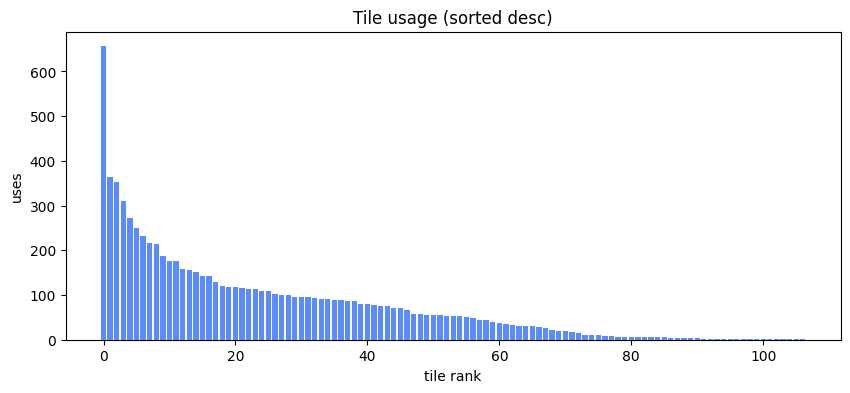

ValueError: arrays must be of dtype byte, short, float32 or float64

<Figure size 750x750 with 25 Axes>

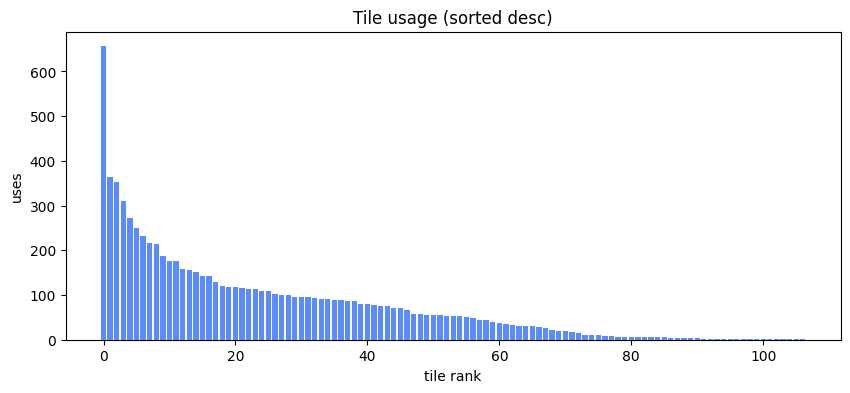

ValueError: arrays must be of dtype byte, short, float32 or float64

<Figure size 750x750 with 25 Axes>

In [7]:
# Cell 7 — self-deprecating report
report = build_report(assignment, tile_records, elapsed, bad_files)
(config.out_dir / 'report.txt').write_text(report.text, encoding='utf-8')
print(report.text)
plt.show()  # flushes any pending figure
display(report.usage_bar_fig)
display(report.cold_wall_fig)

In [8]:
# Cell 8 — DeepZoom export
index_html = export_deepzoom(mosaic_path, config.out_dir / 'deepzoom')
print(f'✅ 已生成 {index_html},在浏览器打开即可无限缩放')

✅ 已生成 out/deepzoom/index.html,在浏览器打开即可无限缩放
